In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [33]:
df = pd.read_csv("Churn Prdiction Data/churn-bigml-80.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [35]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [36]:
X = df[[
    'Account length',
    'Total day minutes',
    'Total eve minutes',
    'Total night minutes',
    'Customer service calls'
]]

X.head()

,Account length,Total day minutes,Total eve minutes,Total night minutes,Customer service calls
0,128,265.1,197.4,244.7,1
1,107,161.6,195.5,254.4,1
2,137,243.4,121.2,162.6,0
3,84,299.4,61.9,196.9,2
4,75,166.7,148.3,186.9,3


In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Standardized Successfully")

Data Standardized Successfully


In [38]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

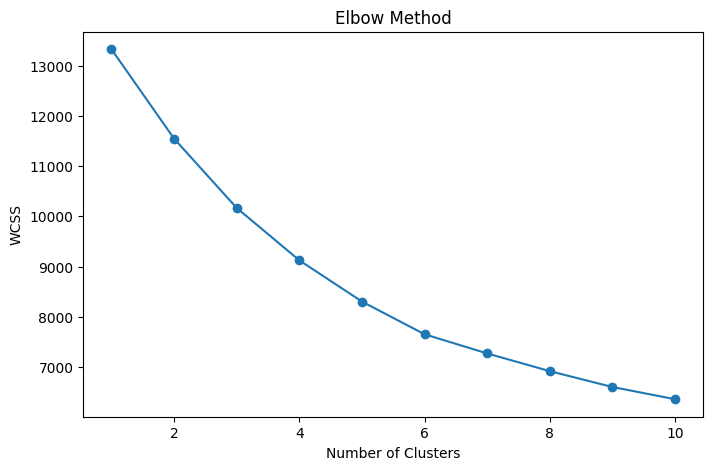

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [41]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Cluster
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,...,16.78,244.7,91,11.01,10.0,3,2.70,1,False,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,...,16.62,254.4,103,11.45,13.7,3,3.70,1,False,3
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,...,10.30,162.6,104,7.32,12.2,5,3.29,0,False,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,...,5.26,196.9,89,8.86,6.6,7,1.78,2,False,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,...,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1


In [42]:
df['Cluster'].value_counts()

Cluster
3    776
0    725
2    702
1    463
Name: count, dtype: int64

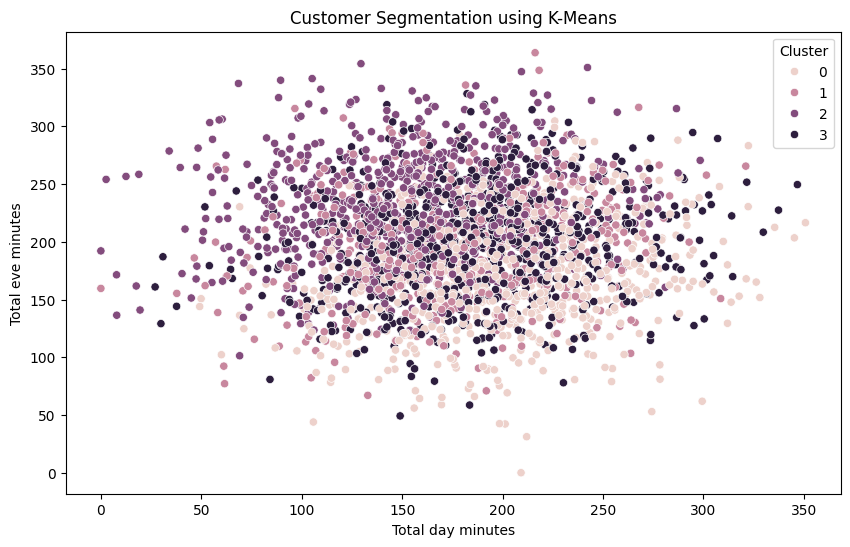

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Total day minutes',
    y='Total eve minutes',
    hue='Cluster'
)

plt.title("Customer Segmentation using K-Means")

plt.show()

In [44]:
cluster_summary = df.groupby('Cluster')[[
    'Total day minutes',
    'Total eve minutes',
    'Total night minutes',
    'Customer service calls'
]].mean()

cluster_summary

,Total day minutes,Total eve minutes,Total night minutes,Customer service calls
Cluster,,,,
0,199.868552,172.434483,214.985931,1.137931
1,176.762419,199.127214,198.304320,3.710583
2,151.373077,231.399145,162.065385,1.044160
3,187.485052,199.196392,225.343814,1.146907


In [45]:
df.to_csv("customer_segments.csv", index=False)

print("Final Output Saved Successfully")

Final Output Saved Successfully


 Conclusion

- Customer data was preprocessed and standardized using StandardScaler.
- The Elbow Method was used to determine the optimal number of clusters.
- Based on the Elbow Method, 4 clusters were selected.
- K-Means clustering successfully segmented customers into 4 groups.
- These customer segments can help businesses understand customer behavior and support targeted marketing strategies.